c:\customer-churn-ai\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Training size: (5634, 33)
Test size: (1409, 33)
Churn rate in training: 26.54%


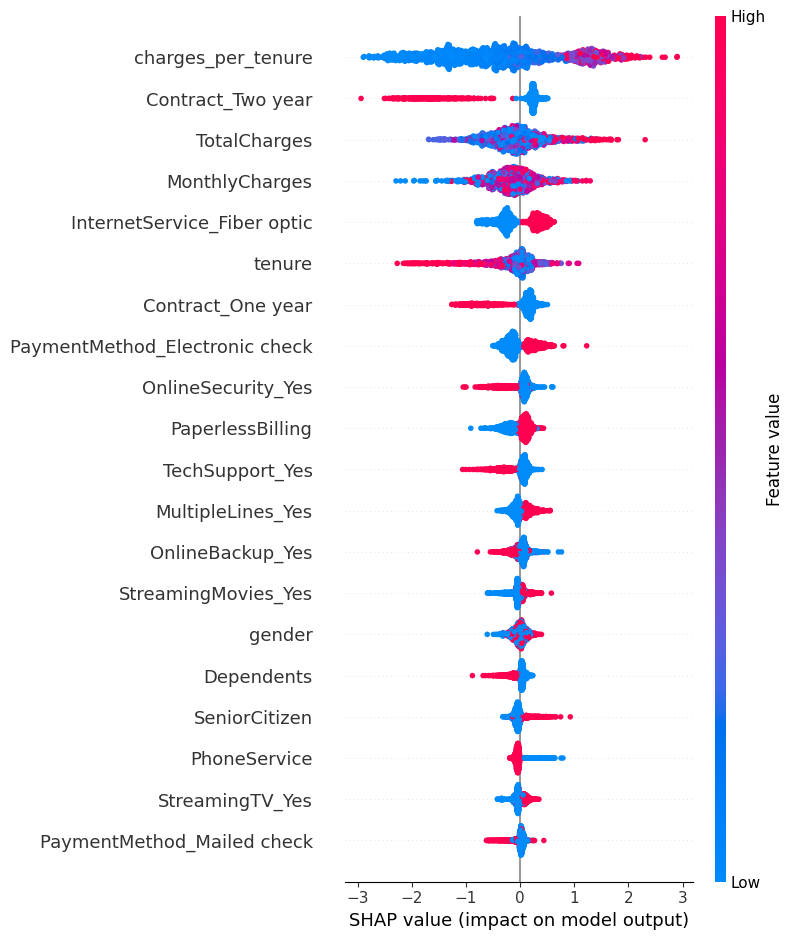

In [1]:
import os
os.chdir(os.path.dirname(os.path.abspath('02_model_evaluation.ipynb')))
import shap
import joblib
import sys
sys.path.append('../preprocessing')
from preprocess import load_and_clean_data, encode_features, feature_engineering, split_and_scale

df = load_and_clean_data('../../data/telco_churn.csv')
df = encode_features(df)
df = feature_engineering(df)
X_train, X_test, y_train, y_test, features = split_and_scale(df)

# Load XGBoost (best model)
model = joblib.load('../saved_models/XGBoost.pkl')

# SHAP explainer
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Summary plot — shows which features matter most globally
shap.summary_plot(shap_values, X_test, feature_names=list(features))

In [2]:
# Explain prediction for customer #0
shap.initjs()
shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    X_test[0],
    feature_names=list(features)
)
# This shows EXACTLY why this specific customer was flagged

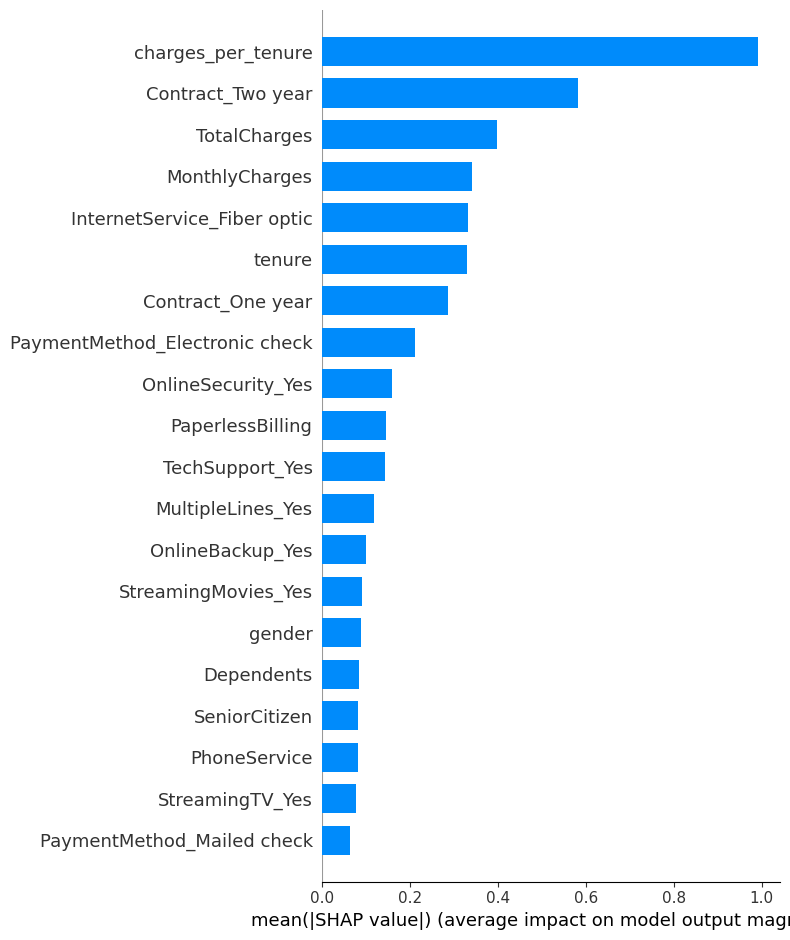

In [3]:
shap.summary_plot(shap_values, X_test,
                   feature_names=list(features),
                   plot_type='bar')
# Top features typically: tenure, MonthlyCharges, Contract_Month-to-month